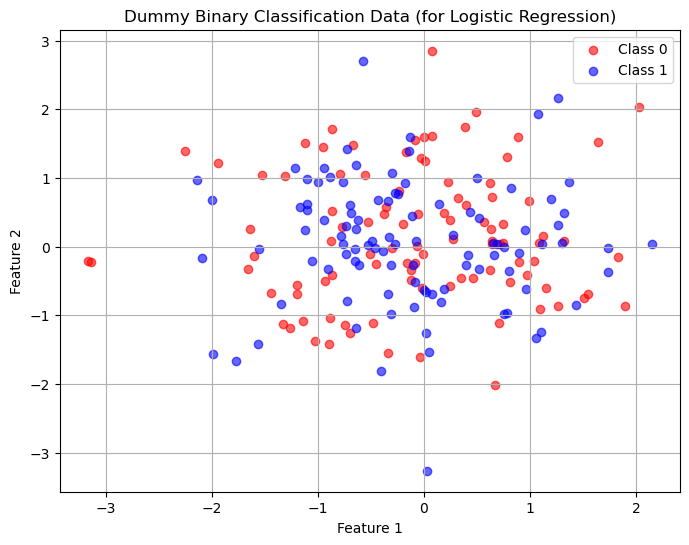

Features shape: (200, 784)
Target shape: (200,)


In [209]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


# Set seed
np.random.seed(42)

# Generate a classification dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [210]:
# Center test data
X_test_centered = X_test - np.mean(X_test, axis=0)

# Covariance matrix
cov = np.cov(X_test_centered.T)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov)

# Sort eigenvectors
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, sorted_idx]

# Take top 2 principal components
w = eig_vecs[:, :2]

# Reduce test data to 2D
X_test_pca = X_test_centered @ W

# Plot using TRUE labels
y_test_plot = y_test.flatten()


print(w.shape)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 784 is different from 2)

In [208]:
mean = np.mean(X, axis=0)
std = np.std(X,axis=0)
X = (X-mean)/std

In [197]:
split = int(0.8 * X.shape[0]) 

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]


In [203]:
# w = np.random.randn(1, X.shape[1])
b = np.array([[0]])
# X_train = X
# y_train = y.reshape(-1,1)


m= X_train.shape[0]
alpha = 0.01
cost_history = []

for i in range(1000):
   
    z = (X_train @w .T )+b
    y_ = 1/(1+(np.exp(-z)))
    # cost = np.mean(-(y_train)* np.log(y_)) - ((1 - y_train) * np.log(1 - y_)))
    cost = np.mean(-(y_train * np.log(y_train+0.000000001)) - ((1 - y_train) * np.log(1 - y_train+0.000000001)))
    cost_history.append(cost)
    
    djdw =(X_train.T @ (y_ - y_train)).T / m
    djdb = (np.sum(y_ - y_train)) / m
        
    w = w - alpha * djdw
    b = b - alpha * djdb
y = y.flatten()
plt.scatter(X_train[y_train == 0][:,0], X_train[y_train== 0][:,1],color="red", label="Class 0", alpha=0.6)

plt.scatter(X_train[y_train== 1][:,0], X_train[y_train== 1][:,1],color="blue", label="Class 1", alpha=0.6)    

x1 = X_train[:,0]
x2 =(-w[0][0]*x1-b[0][0])/w[0][1]

z_test = X_test @ w.T + b
y_test_prob = 1 / (1 + np.exp(-z_test))

y_pred = (y_test_prob >= 0.5).astype(int)

accuracy = np.mean(y_pred == y_test.reshape(-1,1)) * 100

print("Test Accuracy:", accuracy)


 
plt.plot(x1,x2)
plt.show()

plt.plot(cost_history)
plt.show()
    
    
                     



ValueError: operands could not be broadcast together with shapes (160,784) (160,) 

In [204]:
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)
print(y_pred.shape)

(160, 2)
(40, 2)
(40,)
(40, 160)


In [205]:
print(X.shape)
print(y.shape)

(200, 2)
(200,)


In [181]:
w.shape

(160, 784)

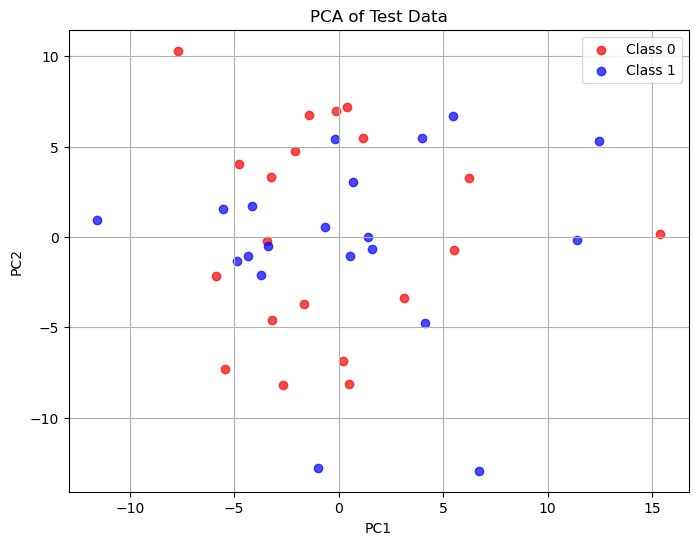

In [191]:
# -----------------------------
# PCA on TEST DATA
# -----------------------------

# Center test data
X_test_centered = X_test - np.mean(X_test, axis=0)

# Covariance matrix
cov = np.cov(X_test_centered.T)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov)

# Sort eigenvectors
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, sorted_idx]

# Take top 2 principal components
W = eig_vecs[:, :2]

# Reduce test data to 2D
X_test_pca = X_test_centered @ W

# Plot using TRUE labels
y_test_plot = y_test.flatten()

plt.figure(figsize=(8,6))

plt.scatter(
    X_test_pca[y_test_plot == 0, 0],
    X_test_pca[y_test_plot == 0, 1],
    color='red',
    label='Class 0',
    alpha=0.7
)

plt.scatter(
    X_test_pca[y_test_plot == 1, 0],
    X_test_pca[y_test_plot == 1, 1],
    color='blue',
    label='Class 1',
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Test Data")
plt.legend()
plt.grid(True)
plt.show()

In [182]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(w.shape)
print(z_test.shape)
print(y_pred.shape)

(160, 784)
(160,)
(40, 784)
(40,)
(160, 784)
(40, 160)
(40, 160)


In [192]:
y_pred.shape

(40, 160)